# DCC

In [5]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train=tf.keras.utils.normalize(x_train, axis=1)  #convert all the values between 0 and 1-> easier for the system to calculate
x_test=tf.keras.utils.normalize(x_test, axis=1)

model=tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu', input_shape=(28*28,)),
    tf.keras.layers.Dense(128, activation='relu',name="features"),
    tf.keras.layers.Dense(10, activation='softmax')
])

#adam: adapts learning rates automatically, fast and stable
#cross entropy loss is used for classification. used when labels are integers; categorical_crossentropy->one-hot encoded
#metrics=['accuracy'] means: After each epoch, show me accuracy.
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=3)



Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9230 - loss: 0.2641
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9668 - loss: 0.1069
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9766 - loss: 0.0738


y:  5


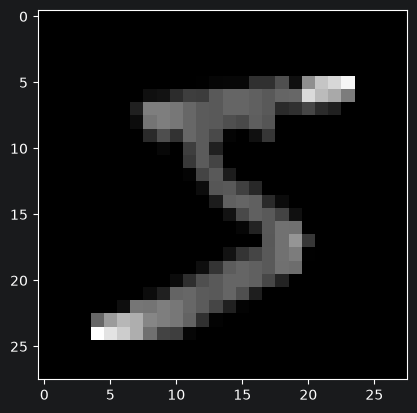

In [6]:
import matplotlib.pyplot as plt
plt.imshow(x_train[0], cmap='gray')
#plt.show()
print("y: ",y_train[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9724 - loss: 0.0882
Test accuracy: 0.9724
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 774us/step
Feature shape: (10000, 128)


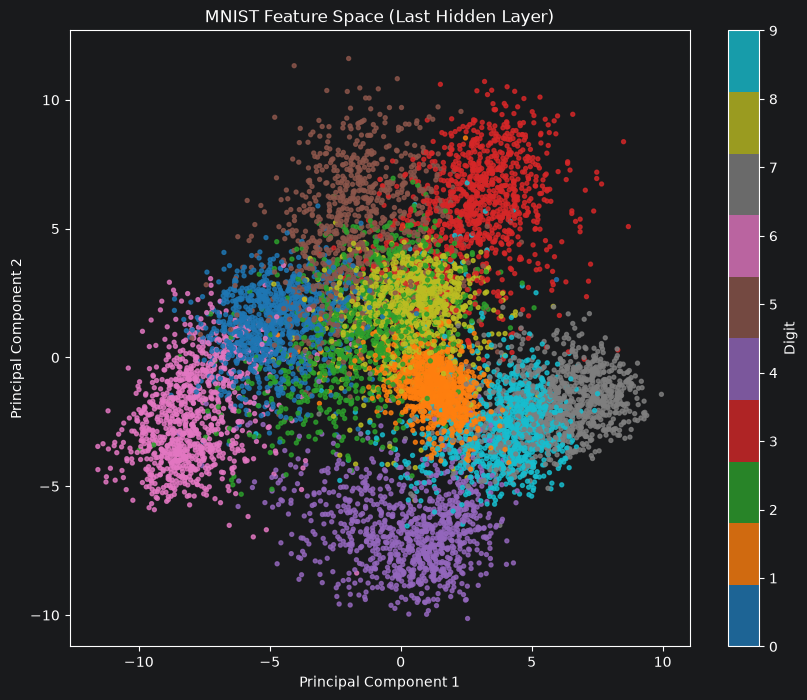

In [7]:
from sklearn.decomposition import PCA
# ----------------------------
# Evaluate
# ----------------------------
test_loss, test_acc = model.evaluate(x_test, y_test)

print(f"Test accuracy: {test_acc:.4f}")

# ----------------------------
# Create a model that outputs the last hidden layer
# ----------------------------
#model.build((None, 28, 28))

feature_model = tf.keras.Model(
    inputs=model.inputs,
    outputs=model.get_layer("features").output
)

# Extract 128-dimensional features
features = feature_model.predict(x_test)

print("Feature shape:", features.shape)
# (10000, 128)

# ----------------------------
# Reduce to 2 dimensions using PCA
# ----------------------------
pca = PCA(n_components=2)
features_2d = pca.fit_transform(features)

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    features_2d[:, 0],
    features_2d[:, 1],
    c=y_test,
    cmap='tab10',
    s=8,
    alpha=0.8
)

plt.colorbar(scatter, ticks=range(10), label="Digit")
plt.title("MNIST Feature Space (Last Hidden Layer)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

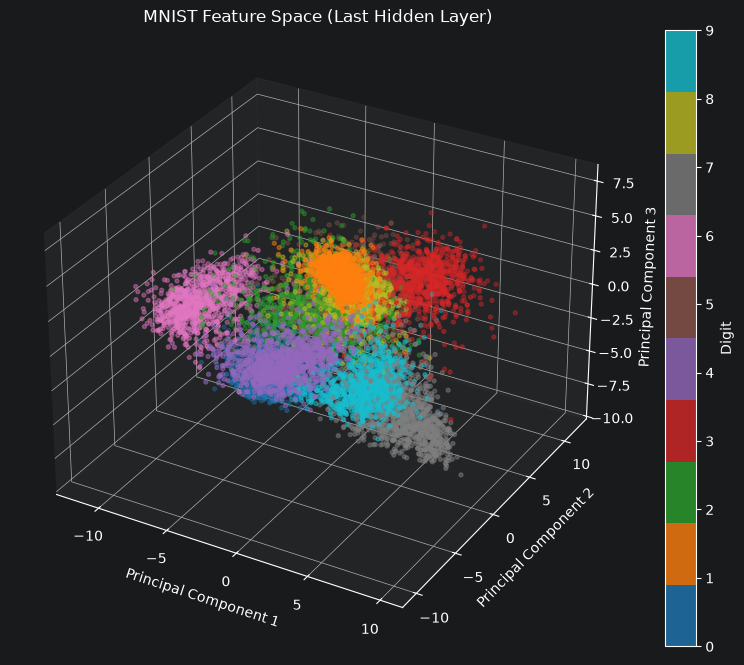

In [8]:
from mpl_toolkits.mplot3d import Axes3D  # Optional in newer Matplotlib versions

# ----------------------------
# Reduce to 3 dimensions using PCA
# ----------------------------
pca3d = PCA(n_components=3)
features_3d = pca3d.fit_transform(features)

# ----------------------------
# Create a 3D figure
# ----------------------------
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    features_3d[:, 0],   # x
    features_3d[:, 1],   # y
    features_3d[:, 2],   # z
    c=y_test,
    cmap='tab10',
    s=8,
    alpha=0.8
)

fig.colorbar(scatter, ticks=range(10), label="Digit")

ax.set_title("MNIST Feature Space (Last Hidden Layer)")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 907us/step


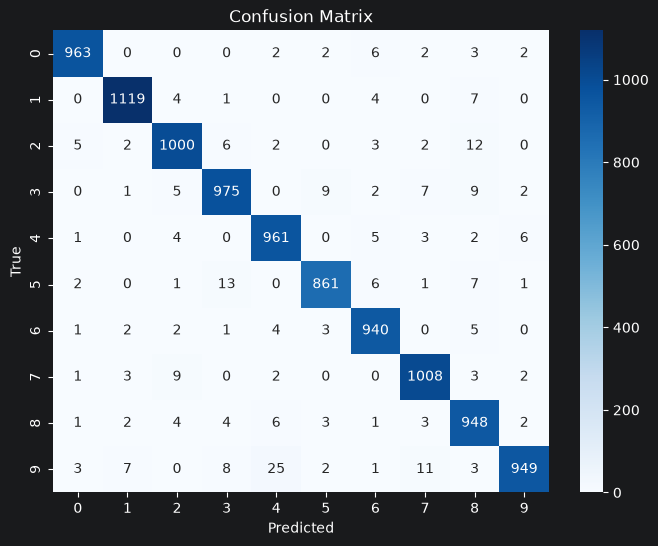

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [10]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.97      0.97      1032
           3       0.97      0.97      0.97      1010
           4       0.96      0.98      0.97       982
           5       0.98      0.97      0.97       892
           6       0.97      0.98      0.98       958
           7       0.97      0.98      0.98      1028
           8       0.95      0.97      0.96       974
           9       0.98      0.94      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



# DNN-2

## underfitting?

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6457 - loss: 1.1435 - val_accuracy: 0.7767 - val_loss: 0.7773
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7954 - loss: 0.7026 - val_accuracy: 0.8150 - val_loss: 0.6459
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8177 - loss: 0.6217 - val_accuracy: 0.8274 - val_loss: 0.5961
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8282 - loss: 0.5835 - val_accuracy: 0.8353 - val_loss: 0.5725
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8358 - loss: 0.5595 - val_accuracy: 0.8370 - val_loss: 0.5573
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8408 - loss: 0.5426 - val_accuracy: 0.8460 - val_loss: 0.5401
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8445 - loss: 0.5295 - val_accuracy: 0.8468 - val_loss: 0.5325
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8469 - loss: 0.5196 - 

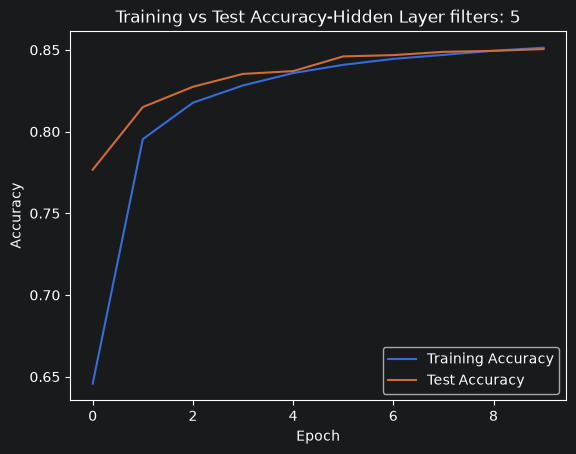

In [11]:
from tensorflow.keras.callbacks import EarlyStopping

model_test=tf.keras.Sequential([
tf.keras.layers.Input(shape=(28, 28)),
tf.keras.layers.Flatten(),
tf.keras.layers.Dense(4, activation='relu'),
#tf.keras.layers.Dense(20, activation='relu',name="features"),
tf.keras.layers.Dense(10, activation='softmax')
])

early_stop = EarlyStopping(
    monitor='val_accuracy',   # or 'val_loss'
    patience=2,               # how many epochs to wait before stopping
    restore_best_weights=True # keeps best model automatically
)

#adam: adapts learning rates automatically, fast and stable
#cross entropy loss is used for classification. used when labels are integers; categorical_crossentropy->one-hot encoded
#metrics=['accuracy'] means: After each epoch, show me accuracy.
model_test.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model_test.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test, y_test),  # this gives test/validation accuracy per epoch
    callbacks=[early_stop]
)

#test_loss, test_acc = model.evaluate(x_test, y_test)

#print(f"Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Test Accuracy-Hidden Layer filters: 5')
plt.legend()
plt.show()

### 1 hidden layer: 8 filters

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8266 - loss: 0.6321 - val_accuracy: 0.9003 - val_loss: 0.3584
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9015 - loss: 0.3372 - val_accuracy: 0.9125 - val_loss: 0.3132
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9111 - loss: 0.3068 - val_accuracy: 0.9164 - val_loss: 0.3008
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9161 - loss: 0.2925 - val_accuracy: 0.9187 - val_loss: 0.2899
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9186 - loss: 0.2836 - val_accuracy: 0.9168 - val_loss: 0.2889


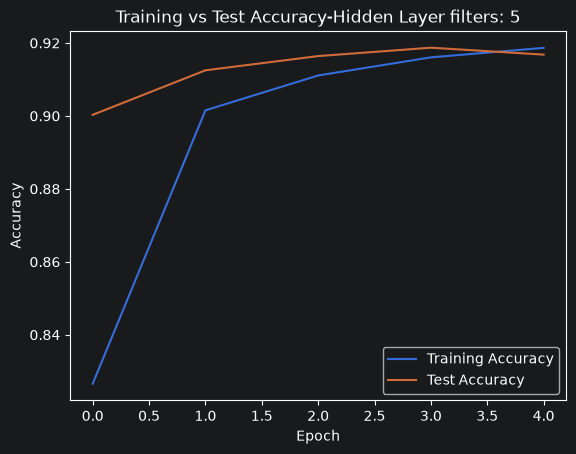

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

model_test=tf.keras.Sequential([
tf.keras.layers.Input(shape=(28, 28)),
tf.keras.layers.Flatten(),
tf.keras.layers.Dense(8, activation='relu'),
#tf.keras.layers.Dense(20, activation='relu',name="features"),
tf.keras.layers.Dense(10, activation='softmax')
])

early_stop = EarlyStopping(
    monitor='val_accuracy',   # or 'val_loss'
    patience=2,               # how many epochs to wait before stopping
    restore_best_weights=True # keeps best model automatically
)

#adam: adapts learning rates automatically, fast and stable
#cross entropy loss is used for classification. used when labels are integers; categorical_crossentropy->one-hot encoded
#metrics=['accuracy'] means: After each epoch, show me accuracy.
model_test.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model_test.fit(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_test, y_test),  # this gives test/validation accuracy per epoch
    callbacks=[early_stop]
)

#test_loss, test_acc = model.evaluate(x_test, y_test)

#print(f"Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Test Accuracy-Hidden Layer filters: 5')
plt.legend()
plt.show()

### 2 hidden layers: 4 for each

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.6407 - loss: 1.2240 - val_accuracy: 0.7673 - val_loss: 0.8828
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7900 - loss: 0.7931 - val_accuracy: 0.8095 - val_loss: 0.7307
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8124 - loss: 0.6949 - val_accuracy: 0.8224 - val_loss: 0.6724
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8246 - loss: 0.6496 - val_accuracy: 0.8330 - val_loss: 0.6357
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8307 - loss: 0.6218 - val_accuracy: 0.8351 - val_loss: 0.6167


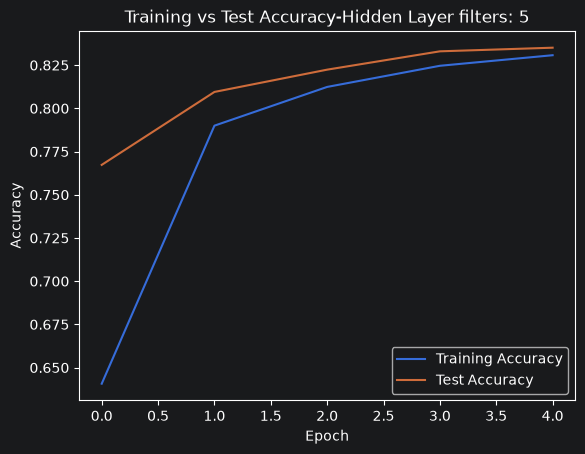

In [13]:
from tensorflow.keras.callbacks import EarlyStopping

model_test=tf.keras.Sequential([
tf.keras.layers.Input(shape=(28, 28)),
tf.keras.layers.Flatten(),
tf.keras.layers.Dense(4, activation='relu'),
tf.keras.layers.Dense(4, activation='relu',name="features"),
tf.keras.layers.Dense(10, activation='softmax')
])

early_stop = EarlyStopping(
    monitor='val_accuracy',   # or 'val_loss'
    patience=2,               # how many epochs to wait before stopping
    restore_best_weights=True # keeps best model automatically
)

#adam: adapts learning rates automatically, fast and stable
#cross entropy loss is used for classification. used when labels are integers; categorical_crossentropy->one-hot encoded
#metrics=['accuracy'] means: After each epoch, show me accuracy.
model_test.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model_test.fit(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_test, y_test),  # this gives test/validation accuracy per epoch
    callbacks=[early_stop]
)

#test_loss, test_acc = model.evaluate(x_test, y_test)

#print(f"Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Test Accuracy-Hidden Layer filters: 5')
plt.legend()
plt.show()

In [14]:
def model_num_of_neurons_in_hidden_layer(num_of_neurons):

    model=tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(num_of_neurons, activation='relu'),
    #tf.keras.layers.Dense(20, activation='relu',name="features"),
    tf.keras.layers.Dense(10, activation='softmax')
    ])

    #adam: adapts learning rates automatically, fast and stable
    #cross entropy loss is used for classification. used when labels are integers; categorical_crossentropy->one-hot encoded
    #metrics=['accuracy'] means: After each epoch, show me accuracy.
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(
        x_train,
        y_train,
        epochs=3,
        validation_data=(x_test, y_test)  # this gives test/validation accuracy per epoch
    )

    #test_loss, test_acc = model.evaluate(x_test, y_test)

    #print(f"Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Test Accuracy')

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'Training vs Test Accuracy (Hidden Layer neurons: {num_of_neurons})')
    plt.legend()
    plt.show()



Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9107 - loss: 0.3181 - val_accuracy: 0.9490 - val_loss: 0.1757
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9575 - loss: 0.1455 - val_accuracy: 0.9637 - val_loss: 0.1259
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9703 - loss: 0.0995 - val_accuracy: 0.9664 - val_loss: 0.1114


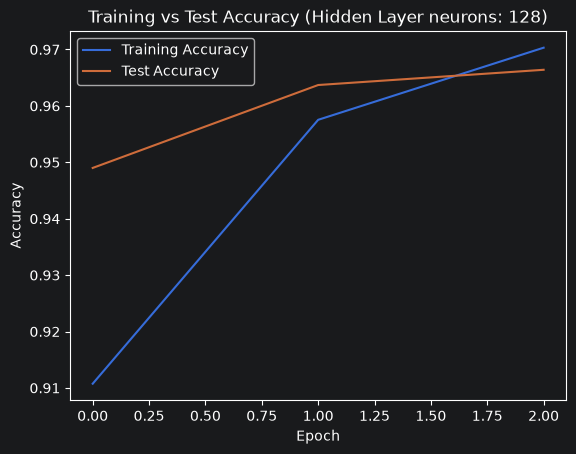

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9144 - loss: 0.3065 - val_accuracy: 0.9475 - val_loss: 0.1697
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9589 - loss: 0.1377 - val_accuracy: 0.9623 - val_loss: 0.1282
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9722 - loss: 0.0935 - val_accuracy: 0.9683 - val_loss: 0.1028


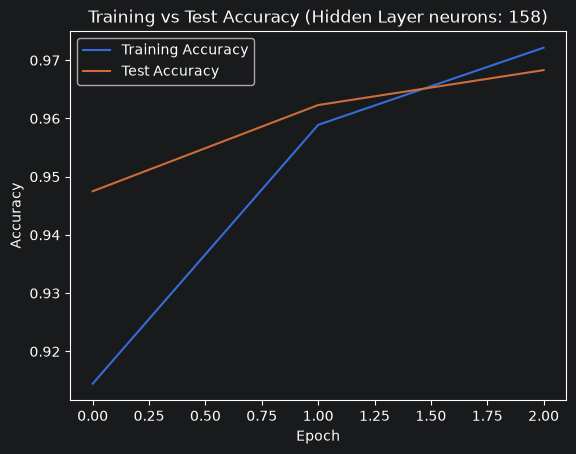

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9188 - loss: 0.2891 - val_accuracy: 0.9544 - val_loss: 0.1530
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9634 - loss: 0.1235 - val_accuracy: 0.9661 - val_loss: 0.1112
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9754 - loss: 0.0834 - val_accuracy: 0.9715 - val_loss: 0.0989


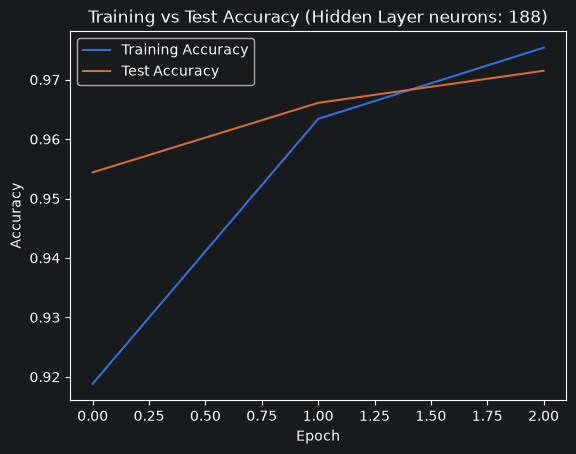

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9208 - loss: 0.2818 - val_accuracy: 0.9560 - val_loss: 0.1492
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9651 - loss: 0.1193 - val_accuracy: 0.9677 - val_loss: 0.1067
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9769 - loss: 0.0799 - val_accuracy: 0.9742 - val_loss: 0.0913


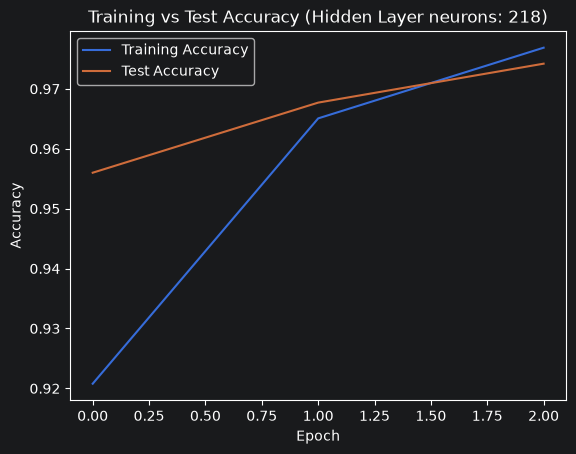

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9239 - loss: 0.2736 - val_accuracy: 0.9571 - val_loss: 0.1477
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9652 - loss: 0.1139 - val_accuracy: 0.9691 - val_loss: 0.1024
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9769 - loss: 0.0750 - val_accuracy: 0.9683 - val_loss: 0.0988


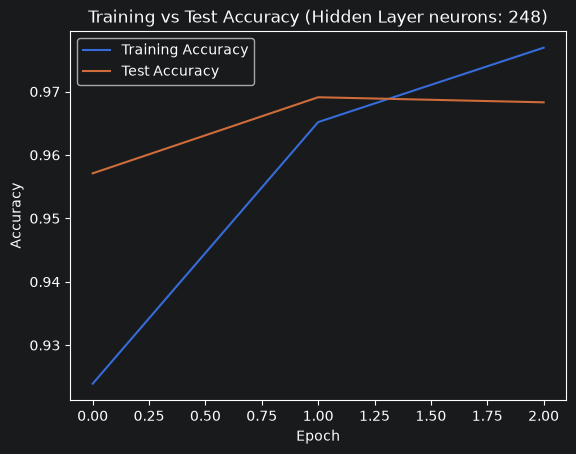

In [15]:
for n in range(128,256,30):
    model_num_of_neurons_in_hidden_layer(n)

In [16]:
def model_num_of_neurons_in_2_hidden_layer(num_of_neurons, number_of_epochs):

    model=tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(num_of_neurons, activation='relu'),
    tf.keras.layers.Dense(num_of_neurons, activation='relu',name="features"),
    tf.keras.layers.Dense(10, activation='softmax')
    ])

    #adam: adapts learning rates automatically, fast and stable
    #cross entropy loss is used for classification. used when labels are integers; categorical_crossentropy->one-hot encoded
    #metrics=['accuracy'] means: After each epoch, show me accuracy.
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(
        x_train,
        y_train,
        epochs=number_of_epochs,
        validation_data=(x_test, y_test)  # this gives test/validation accuracy per epoch
    )

    #test_loss, test_acc = model.evaluate(x_test, y_test)

    #print(f"Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Test Accuracy')

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'Training vs Test Accuracy (Hidden Layer neurons: {num_of_neurons})')
    plt.legend()
    plt.show()

## overfitting

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9212 - loss: 0.2675 - val_accuracy: 0.9590 - val_loss: 0.1309
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9665 - loss: 0.1073 - val_accuracy: 0.9707 - val_loss: 0.0987
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9765 - loss: 0.0738 - val_accuracy: 0.9672 - val_loss: 0.1003
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9824 - loss: 0.0541 - val_accuracy: 0.9740 - val_loss: 0.0869
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9871 - loss: 0.0407 - val_accuracy: 0.9743 - val_loss: 0.0881
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9901 - loss: 0.0309 - val_accuracy: 0.9717 - val_loss: 0.1035
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9912 - loss: 0.0260 - val_accuracy: 0.9762 - val_loss: 0.0911
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9931 - loss: 0.0209 - 

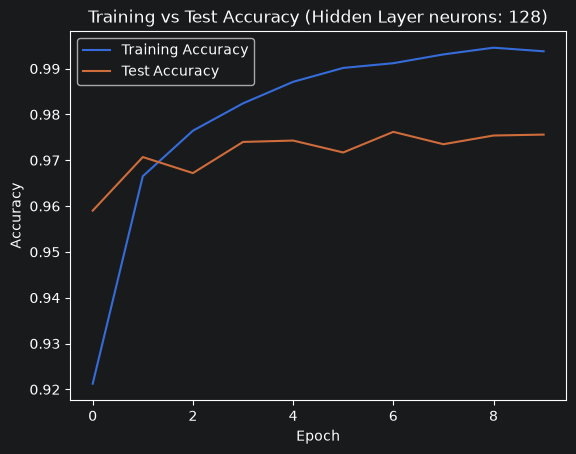

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9245 - loss: 0.2611 - val_accuracy: 0.9605 - val_loss: 0.1260
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9670 - loss: 0.1075 - val_accuracy: 0.9674 - val_loss: 0.1023
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9780 - loss: 0.0709 - val_accuracy: 0.9712 - val_loss: 0.0965
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9830 - loss: 0.0529 - val_accuracy: 0.9711 - val_loss: 0.0968
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9869 - loss: 0.0396 - val_accuracy: 0.9732 - val_loss: 0.0924
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9895 - loss: 0.0307 - val_accuracy: 0.9752 - val_loss: 0.0925
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9920 - loss: 0.0240 - val_accuracy: 0.9766 - val_loss: 0.0860
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9936 - loss: 0.0194 - 

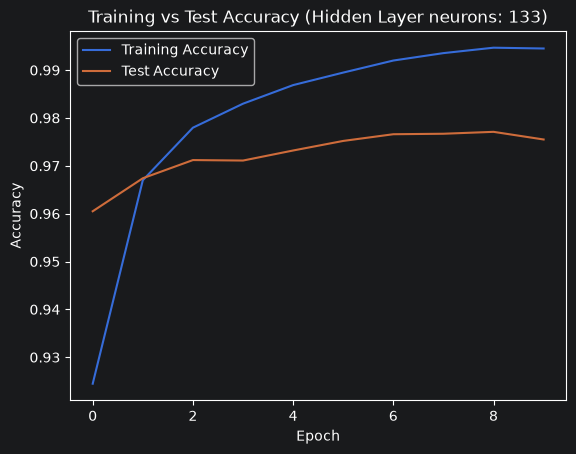

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9224 - loss: 0.2613 - val_accuracy: 0.9584 - val_loss: 0.1346
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9664 - loss: 0.1066 - val_accuracy: 0.9664 - val_loss: 0.1088
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9771 - loss: 0.0738 - val_accuracy: 0.9720 - val_loss: 0.0911
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9825 - loss: 0.0538 - val_accuracy: 0.9701 - val_loss: 0.1031
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9867 - loss: 0.0411 - val_accuracy: 0.9731 - val_loss: 0.0956
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9902 - loss: 0.0307 - val_accuracy: 0.9763 - val_loss: 0.0903
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9914 - loss: 0.0261 - val_accuracy: 0.9752 - val_loss: 0.1004
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9931 - loss: 0.0205 - 

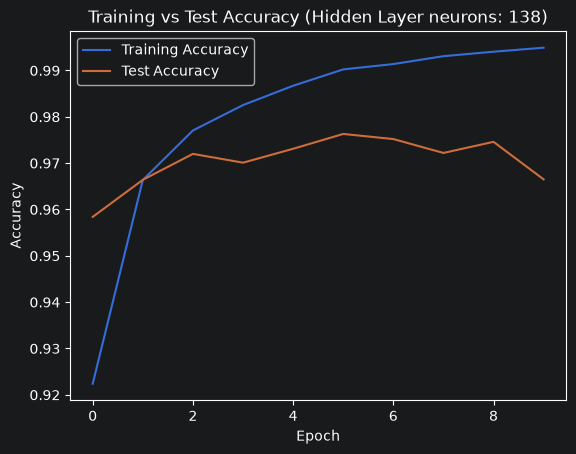

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9249 - loss: 0.2567 - val_accuracy: 0.9519 - val_loss: 0.1550
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9673 - loss: 0.1045 - val_accuracy: 0.9669 - val_loss: 0.1041
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9778 - loss: 0.0700 - val_accuracy: 0.9633 - val_loss: 0.1179
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9841 - loss: 0.0504 - val_accuracy: 0.9750 - val_loss: 0.0803
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9876 - loss: 0.0388 - val_accuracy: 0.9721 - val_loss: 0.0894
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9897 - loss: 0.0303 - val_accuracy: 0.9719 - val_loss: 0.0967
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9922 - loss: 0.0239 - val_accuracy: 0.9762 - val_loss: 0.0907
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9932 - loss: 0.0201 - 

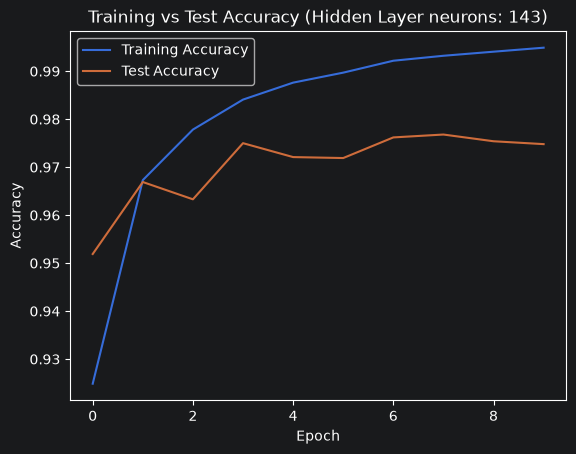

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9244 - loss: 0.2552 - val_accuracy: 0.9601 - val_loss: 0.1358
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9681 - loss: 0.1018 - val_accuracy: 0.9696 - val_loss: 0.1033
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9781 - loss: 0.0683 - val_accuracy: 0.9704 - val_loss: 0.0973
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9840 - loss: 0.0497 - val_accuracy: 0.9740 - val_loss: 0.0861
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9873 - loss: 0.0379 - val_accuracy: 0.9735 - val_loss: 0.0892
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9900 - loss: 0.0307 - val_accuracy: 0.9764 - val_loss: 0.0875
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9923 - loss: 0.0237 - val_accuracy: 0.9731 - val_loss: 0.1028
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9935 - loss: 0.0187 - 

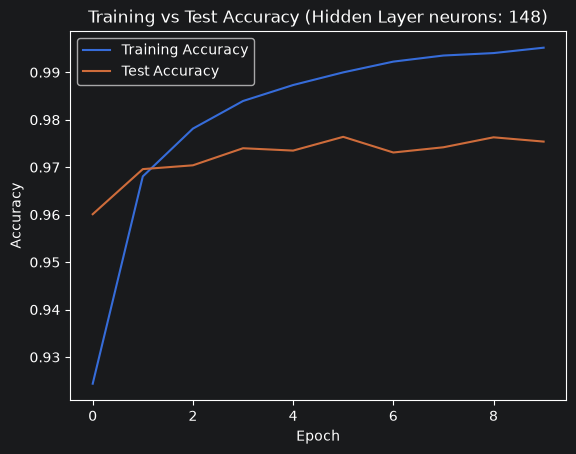

In [17]:
for n in range(128,150,5):
    model_num_of_neurons_in_2_hidden_layer(n, 10)

In [18]:
def model_numOfNeurons_numOfLayers_numOfEpochs(num_of_neurons, num_of_layers,number_of_epochs):

    inputs = tf.keras.Input(shape=(28, 28))

    x = tf.keras.layers.Flatten()(inputs)
    hidden_layer = tf.keras.layers.Dense(num_of_neurons, activation="relu")(x)
    for n in range(num_of_layers):
        hidden_layer = tf.keras.layers.Dense(num_of_neurons, activation="relu")(hidden_layer)

    outputs = tf.keras.layers.Dense(10, activation="softmax")(hidden_layer)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    early_stop = EarlyStopping(
    monitor='val_accuracy',   # or 'val_loss'
    patience=2,               # how many epochs to wait before stopping
    restore_best_weights=True # keeps best model automatically
)

    #adam: adapts learning rates automatically, fast and stable
    #cross entropy loss is used for classification. used when labels are integers; categorical_crossentropy->one-hot encoded
    #metrics=['accuracy'] means: After each epoch, show me accuracy.
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(
        x_train,
        y_train,
        epochs=number_of_epochs,
        validation_data=(x_test, y_test),  # this gives test/validation accuracy per epoch
        callbacks=[early_stop]

    )

    model.summary()

    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Test Accuracy')

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'Training vs Test Accuracy (Hidden Layer neurons: {num_of_neurons})')
    plt.legend()
    plt.show()

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8468 - loss: 0.4945 - val_accuracy: 0.9175 - val_loss: 0.2815
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9337 - loss: 0.2186 - val_accuracy: 0.9360 - val_loss: 0.2204
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9463 - loss: 0.1772 - val_accuracy: 0.9476 - val_loss: 0.1834
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9528 - loss: 0.1549 - val_accuracy: 0.9497 - val_loss: 0.1690
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9578 - loss: 0.1376 - val_accuracy: 0.9535 - val_loss: 0.1593
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9611 - loss: 0.1263 - val_accuracy: 0.9559 - val_loss: 0.1524
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9640 - loss: 0.1168 - val_accuracy: 0.9561 - val_loss: 0.1503
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9662 - loss: 0.1091 - 

Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 20)             │        15,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 10)             │           210 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,512 (201.22 KB)

 Trainable params: 17,170 (67.07 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 34,342 (134.15 KB)

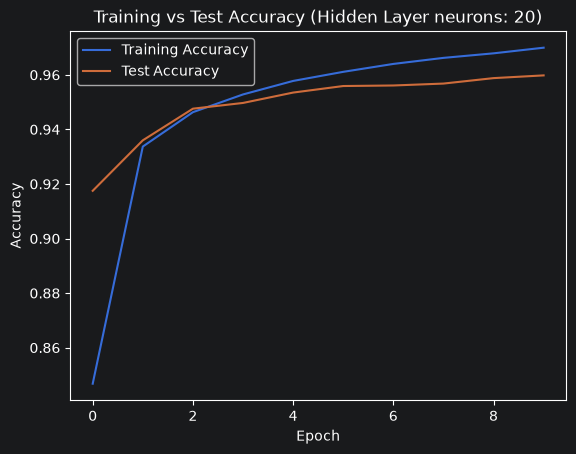

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8583 - loss: 0.4631 - val_accuracy: 0.9291 - val_loss: 0.2374
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9355 - loss: 0.2107 - val_accuracy: 0.9432 - val_loss: 0.1845
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9492 - loss: 0.1628 - val_accuracy: 0.9432 - val_loss: 0.1813
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9564 - loss: 0.1377 - val_accuracy: 0.9500 - val_loss: 0.1620
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9625 - loss: 0.1207 - val_accuracy: 0.9549 - val_loss: 0.1471
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9655 - loss: 0.1092 - val_accuracy: 0.9519 - val_loss: 0.1552
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9696 - loss: 0.0978 - val_accuracy: 0.9530 - val_loss: 0.1569


Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 24)             │        18,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 24)             │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 24)             │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 24)             │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 10)             │           250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,672 (244.82 KB)

 Trainable params: 20,890 (81.60 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 41,782 (163.21 KB)

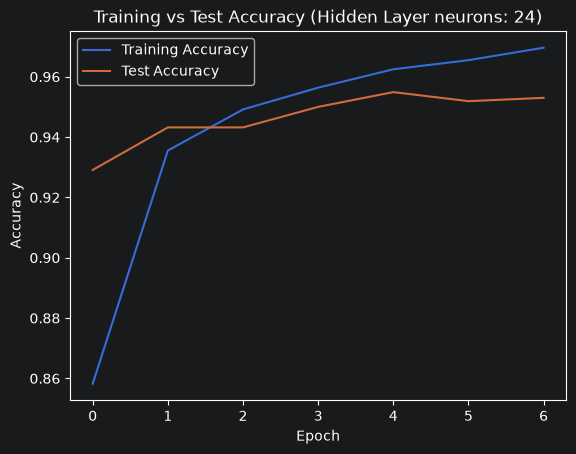

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8747 - loss: 0.4010 - val_accuracy: 0.9408 - val_loss: 0.2044
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9437 - loss: 0.1842 - val_accuracy: 0.9505 - val_loss: 0.1670
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9553 - loss: 0.1459 - val_accuracy: 0.9487 - val_loss: 0.1755
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9619 - loss: 0.1240 - val_accuracy: 0.9598 - val_loss: 0.1327
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9668 - loss: 0.1085 - val_accuracy: 0.9600 - val_loss: 0.1356
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9701 - loss: 0.0970 - val_accuracy: 0.9624 - val_loss: 0.1271
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9737 - loss: 0.0871 - val_accuracy: 0.9632 - val_loss: 0.1279
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9744 - loss: 0.0803 - 

Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_17 (InputLayer)     │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_17 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 28)             │        21,980 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 28)             │           812 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 28)             │           812 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 28)             │           812 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 10)             │           290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,120 (289.54 KB)

 Trainable params: 24,706 (96.51 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 49,414 (193.03 KB)

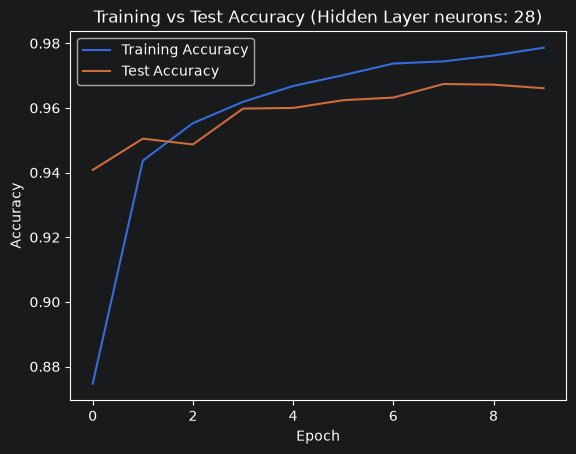

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8719 - loss: 0.4090 - val_accuracy: 0.9375 - val_loss: 0.1984
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9473 - loss: 0.1729 - val_accuracy: 0.9526 - val_loss: 0.1614
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9586 - loss: 0.1354 - val_accuracy: 0.9597 - val_loss: 0.1363
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9638 - loss: 0.1157 - val_accuracy: 0.9580 - val_loss: 0.1395
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9688 - loss: 0.0996 - val_accuracy: 0.9604 - val_loss: 0.1360
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9721 - loss: 0.0890 - val_accuracy: 0.9581 - val_loss: 0.1471
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9753 - loss: 0.0796 - val_accuracy: 0.9628 - val_loss: 0.1298
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9758 - loss: 0.0740 - 

Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_18 (InputLayer)     │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_18 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,856 (335.38 KB)

 Trainable params: 28,618 (111.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 57,238 (223.59 KB)

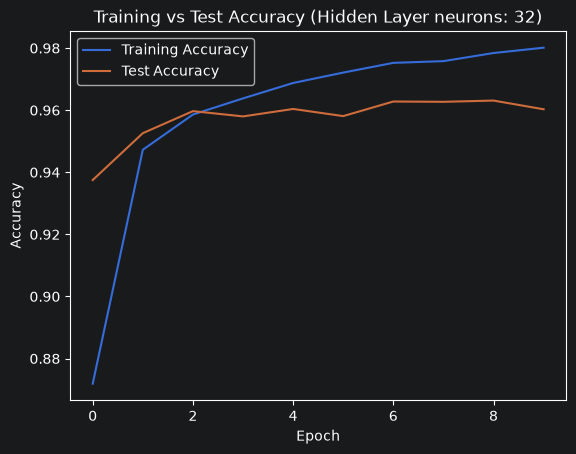

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8816 - loss: 0.3917 - val_accuracy: 0.9353 - val_loss: 0.2095
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9431 - loss: 0.1864 - val_accuracy: 0.9468 - val_loss: 0.1744
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9557 - loss: 0.1434 - val_accuracy: 0.9558 - val_loss: 0.1517
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9639 - loss: 0.1154 - val_accuracy: 0.9581 - val_loss: 0.1456
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9694 - loss: 0.0997 - val_accuracy: 0.9582 - val_loss: 0.1369
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9724 - loss: 0.0883 - val_accuracy: 0.9621 - val_loss: 0.1359
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9755 - loss: 0.0776 - val_accuracy: 0.9619 - val_loss: 0.1314
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9769 - loss: 0.0718 - 

Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_19 (InputLayer)     │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_19 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 36)             │        28,260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 36)             │         1,332 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 36)             │         1,332 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 36)             │         1,332 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 10)             │           370 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,880 (382.35 KB)

 Trainable params: 32,626 (127.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 65,254 (254.90 KB)

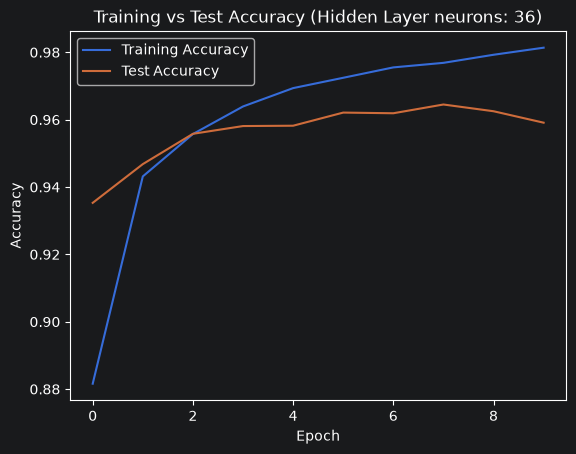

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8871 - loss: 0.3685 - val_accuracy: 0.9400 - val_loss: 0.1985
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9495 - loss: 0.1648 - val_accuracy: 0.9544 - val_loss: 0.1455
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9610 - loss: 0.1253 - val_accuracy: 0.9604 - val_loss: 0.1267
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9682 - loss: 0.1039 - val_accuracy: 0.9627 - val_loss: 0.1253
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9728 - loss: 0.0868 - val_accuracy: 0.9641 - val_loss: 0.1257
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9757 - loss: 0.0762 - val_accuracy: 0.9641 - val_loss: 0.1159
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9785 - loss: 0.0678 - val_accuracy: 0.9640 - val_loss: 0.1186


Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_20 (InputLayer)     │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_20 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 40)             │        31,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 40)             │         1,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 40)             │         1,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 40)             │         1,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 10)             │           410 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,192 (430.44 KB)

 Trainable params: 36,730 (143.48 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 73,462 (286.96 KB)

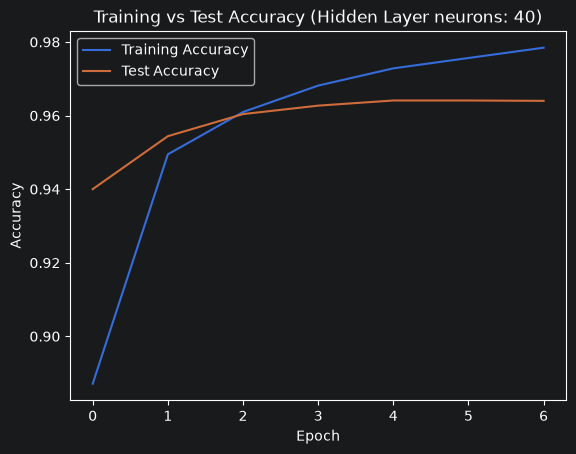

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8924 - loss: 0.3465 - val_accuracy: 0.9430 - val_loss: 0.1867
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9528 - loss: 0.1550 - val_accuracy: 0.9599 - val_loss: 0.1372
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9630 - loss: 0.1188 - val_accuracy: 0.9618 - val_loss: 0.1293
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9702 - loss: 0.0948 - val_accuracy: 0.9648 - val_loss: 0.1228
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9743 - loss: 0.0818 - val_accuracy: 0.9640 - val_loss: 0.1267
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9782 - loss: 0.0700 - val_accuracy: 0.9663 - val_loss: 0.1252
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9803 - loss: 0.0614 - val_accuracy: 0.9686 - val_loss: 0.1157
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9824 - loss: 0.0541 - 

Model: "functional_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_21 (InputLayer)     │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_21 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 44)             │        34,540 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 44)             │         1,980 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 44)             │         1,980 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 44)             │         1,980 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 10)             │           450 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,792 (479.66 KB)

 Trainable params: 40,930 (159.88 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 81,862 (319.78 KB)

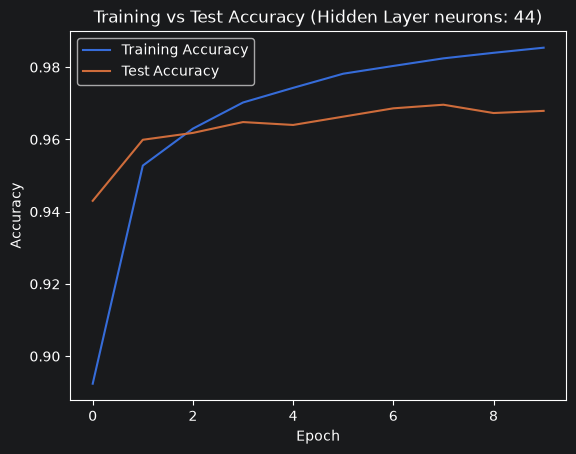

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8957 - loss: 0.3427 - val_accuracy: 0.9463 - val_loss: 0.1873
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9525 - loss: 0.1536 - val_accuracy: 0.9567 - val_loss: 0.1397
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9643 - loss: 0.1136 - val_accuracy: 0.9625 - val_loss: 0.1274
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9721 - loss: 0.0901 - val_accuracy: 0.9658 - val_loss: 0.1226
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9755 - loss: 0.0784 - val_accuracy: 0.9653 - val_loss: 0.1159
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9796 - loss: 0.0646 - val_accuracy: 0.9633 - val_loss: 0.1222


Model: "functional_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_22 (InputLayer)     │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_22 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 48)             │        37,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 48)             │         2,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 48)             │         2,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 48)             │         2,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 10)             │           490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 135,680 (530.00 KB)

 Trainable params: 45,226 (176.66 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 90,454 (353.34 KB)

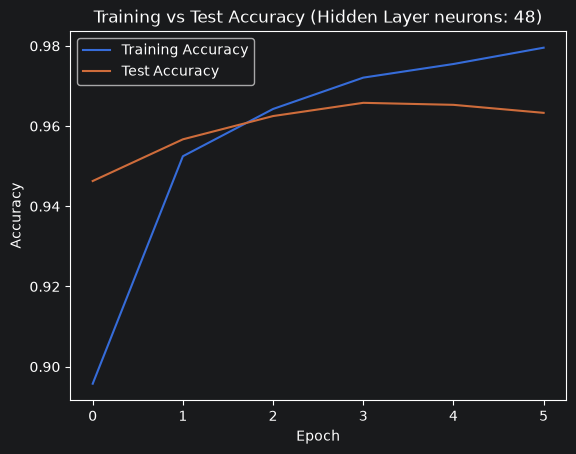

In [19]:
for n in range(20,50,4):
    model_numOfNeurons_numOfLayers_numOfEpochs(n, 3, 10)

## with dropout:


In [20]:
def model_numOfNeurons_numOfLayers_numOfEpochs_withDropout(num_of_neurons, num_of_layers,number_of_epochs):

    inputs = tf.keras.Input(shape=(28, 28))

    x = tf.keras.layers.Flatten()(inputs)
    for n in range(num_of_layers):
        x = tf.keras.layers.Dense(num_of_neurons, activation="relu")(x)
        x = tf.keras.layers.Dropout(0.3)(x)

    outputs = tf.keras.layers.Dense(10, activation="softmax")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    early_stop = EarlyStopping(
    monitor='val_accuracy',   # or 'val_loss'
    patience=2,               # how many epochs to wait before stopping
    restore_best_weights=True # keeps best model automatically
)

    #adam: adapts learning rates automatically, fast and stable
    #cross entropy loss is used for classification. used when labels are integers; categorical_crossentropy->one-hot encoded
    #metrics=['accuracy'] means: After each epoch, show me accuracy.
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(
        x_train,
        y_train,
        epochs=number_of_epochs,
        validation_data=(x_test, y_test),  # this gives test/validation accuracy per epoch
        callbacks=[early_stop]

    )

    model.summary()

    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Test Accuracy')

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'Training vs Test Accuracy (Hidden Layer neurons: {num_of_neurons})')
    plt.legend()
    plt.show()

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8856 - loss: 0.3762 - val_accuracy: 0.9494 - val_loss: 0.1583
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9453 - loss: 0.1818 - val_accuracy: 0.9652 - val_loss: 0.1142
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9574 - loss: 0.1404 - val_accuracy: 0.9701 - val_loss: 0.1001
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9622 - loss: 0.1228 - val_accuracy: 0.9702 - val_loss: 0.0967
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9674 - loss: 0.1063 - val_accuracy: 0.9706 - val_loss: 0.0938
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9704 - loss: 0.0957 - val_accuracy: 0.9756 - val_loss: 0.0883
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9721 - loss: 0.0881 - val_accuracy: 0.9769 - val_loss: 0.0844
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9738 - loss: 0.0833 - 

Model: "functional_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_23 (InputLayer)     │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_23 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_72 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 354,848 (1.35 MB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 236,566 (924.09 KB)

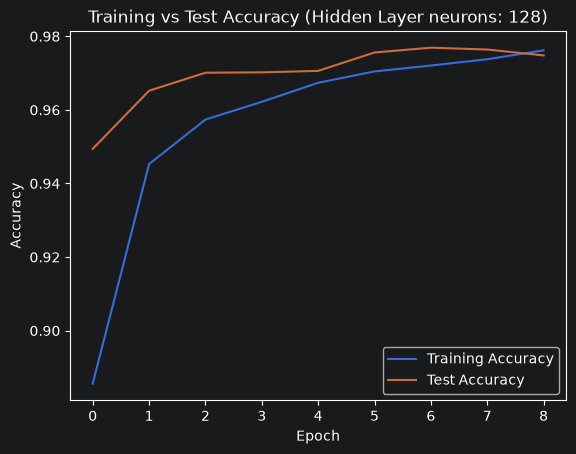

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9007 - loss: 0.3283 - val_accuracy: 0.9532 - val_loss: 0.1454
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9527 - loss: 0.1560 - val_accuracy: 0.9685 - val_loss: 0.1038
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9624 - loss: 0.1239 - val_accuracy: 0.9708 - val_loss: 0.0942
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9681 - loss: 0.1027 - val_accuracy: 0.9748 - val_loss: 0.0897
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9722 - loss: 0.0898 - val_accuracy: 0.9759 - val_loss: 0.0823
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9751 - loss: 0.0799 - val_accuracy: 0.9749 - val_loss: 0.0824
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9765 - loss: 0.0730 - val_accuracy: 0.9764 - val_loss: 0.0798
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9779 - loss: 0.0681 - 

Model: "functional_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_24 (InputLayer)     │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_24 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 178)            │       139,730 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 178)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 178)            │        31,862 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 178)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 10)             │         1,790 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 520,148 (1.98 MB)

 Trainable params: 173,382 (677.27 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 346,766 (1.32 MB)

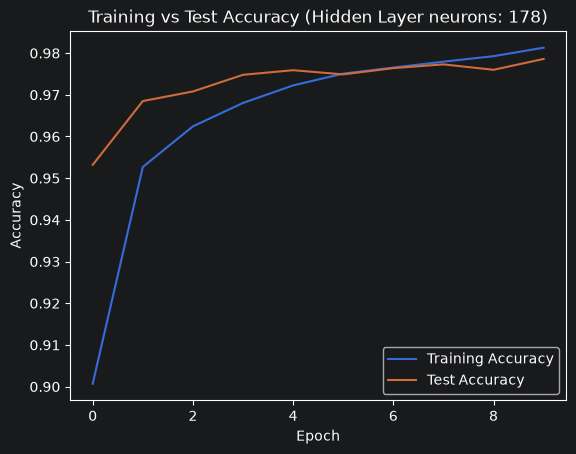

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9094 - loss: 0.3011 - val_accuracy: 0.9582 - val_loss: 0.1287
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9554 - loss: 0.1463 - val_accuracy: 0.9681 - val_loss: 0.1029
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9659 - loss: 0.1104 - val_accuracy: 0.9749 - val_loss: 0.0860
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9719 - loss: 0.0917 - val_accuracy: 0.9759 - val_loss: 0.0814
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9750 - loss: 0.0777 - val_accuracy: 0.9756 - val_loss: 0.0801
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9774 - loss: 0.0706 - val_accuracy: 0.9767 - val_loss: 0.0769
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9802 - loss: 0.0634 - val_accuracy: 0.9765 - val_loss: 0.0819
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9806 - loss: 0.0605 - 

Model: "functional_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_25 (InputLayer)     │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_25 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 228)            │       178,980 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 228)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 228)            │        52,212 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 228)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 10)             │         2,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 700,448 (2.67 MB)

 Trainable params: 233,482 (912.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 466,966 (1.78 MB)

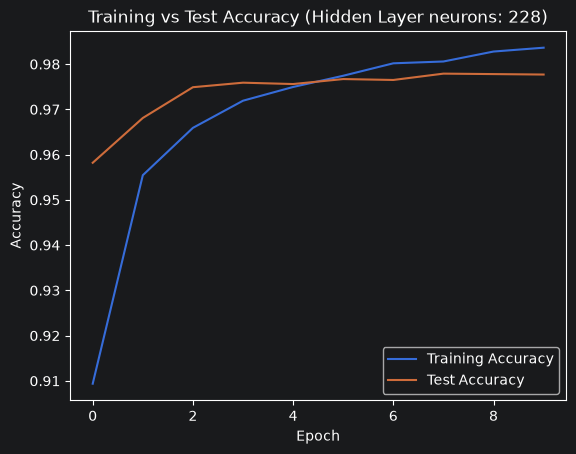

In [21]:
for n in range(128,256,50):
    model_numOfNeurons_numOfLayers_numOfEpochs_withDropout(n, 2, 10)

In [25]:
def model_numOfNeurons_numOfLayers_numOfEpochs_withDropout_nextLayerHalfNeurons(num_of_neurons, num_of_layers,number_of_epochs, degree_dropout=0.3):
    num_of_neurons*=2
    inputs = tf.keras.Input(shape=(28, 28))

    x = tf.keras.layers.Flatten()(inputs)
    for n in range(num_of_layers):
        x = tf.keras.layers.Dense(num_of_neurons//2, activation="relu")(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Dropout(degree_dropout)(x)

    outputs = tf.keras.layers.Dense(10, activation="softmax")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    early_stop = EarlyStopping(
    monitor='val_accuracy',   # or 'val_loss'
    patience=2,               # how many epochs to wait before stopping
    restore_best_weights=True # keeps best model automatically
)

    #adam: adapts learning rates automatically, fast and stable
    #cross entropy loss is used for classification. used when labels are integers; categorical_crossentropy->one-hot encoded
    #metrics=['accuracy'] means: After each epoch, show me accuracy.
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(
        x_train,
        y_train,
        epochs=number_of_epochs,
        validation_data=(x_test, y_test),  # this gives test/validation accuracy per epoch
        callbacks=[early_stop]

    )

    model.summary()

    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Test Accuracy')

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'Training vs Test Accuracy (Hidden Layer neurons: {num_of_neurons})')
    plt.legend()
    plt.show()

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8293 - loss: 0.5548 - val_accuracy: 0.9469 - val_loss: 0.1737
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9110 - loss: 0.3016 - val_accuracy: 0.9579 - val_loss: 0.1331
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9305 - loss: 0.2389 - val_accuracy: 0.9635 - val_loss: 0.1141
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9370 - loss: 0.2150 - val_accuracy: 0.9676 - val_loss: 0.1046
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9442 - loss: 0.1902 - val_accuracy: 0.9674 - val_loss: 0.1022
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9465 - loss: 0.1806 - val_accuracy: 0.9718 - val_loss: 0.0938
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9515 - loss: 0.1606 - val_accuracy: 0.9716 - val_loss: 0.0967
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9552 - loss: 0.1572 

Model: "functional_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_35 (InputLayer)     │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_35 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_117 (Dense)               │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_118 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_119 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_120 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_121 (Dense)               │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 458,016 (1.75 MB)

 Trainable params: 152,330 (595.04 KB)

 Non-trainable params: 1,024 (4.00 KB)

 Optimizer params: 304,662 (1.16 MB)

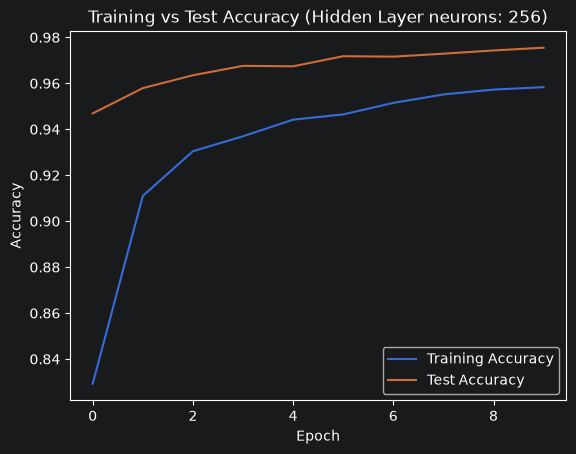

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.8688 - loss: 0.4331 - val_accuracy: 0.9526 - val_loss: 0.1558
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9290 - loss: 0.2379 - val_accuracy: 0.9608 - val_loss: 0.1238
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9416 - loss: 0.1959 - val_accuracy: 0.9687 - val_loss: 0.0987
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9485 - loss: 0.1710 - val_accuracy: 0.9697 - val_loss: 0.0923
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9537 - loss: 0.1489 - val_accuracy: 0.9716 - val_loss: 0.0851
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9576 - loss: 0.1381 - val_accuracy: 0.9746 - val_loss: 0.0811
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9619 - loss: 0.1264 - val_accuracy: 0.9758 - val_loss: 0.0837
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9645 - loss: 0.11

Model: "functional_37"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_36 (InputLayer)     │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_36 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_122 (Dense)               │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_123 (Dense)               │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_124 (Dense)               │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_125 (Dense)               │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_126 (Dense)               │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,210,912 (4.62 MB)

 Trainable params: 402,954 (1.54 MB)

 Non-trainable params: 2,048 (8.00 KB)

 Optimizer params: 805,910 (3.07 MB)

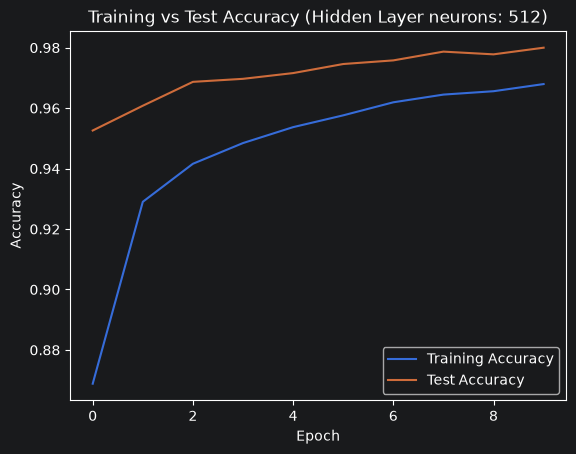

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.8904 - loss: 0.3650 - val_accuracy: 0.9548 - val_loss: 0.1530
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9374 - loss: 0.2093 - val_accuracy: 0.9699 - val_loss: 0.1004
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9492 - loss: 0.1715 - val_accuracy: 0.9687 - val_loss: 0.1009
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9559 - loss: 0.1461 - val_accuracy: 0.9748 - val_loss: 0.0832
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9603 - loss: 0.1296 - val_accuracy: 0.9748 - val_loss: 0.0828
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9621 - loss: 0.1228 - val_accuracy: 0.9781 - val_loss: 0.0708
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9676 - loss: 0.1056 - val_accuracy: 0.9772 - val_loss: 0.0783
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9703 - loss: 0

Model: "functional_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_37 (InputLayer)     │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_37 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_127 (Dense)               │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_129 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_130 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_131 (Dense)               │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,601,440 (13.74 MB)

 Trainable params: 1,199,114 (4.57 MB)

 Non-trainable params: 4,096 (16.00 KB)

 Optimizer params: 2,398,230 (9.15 MB)

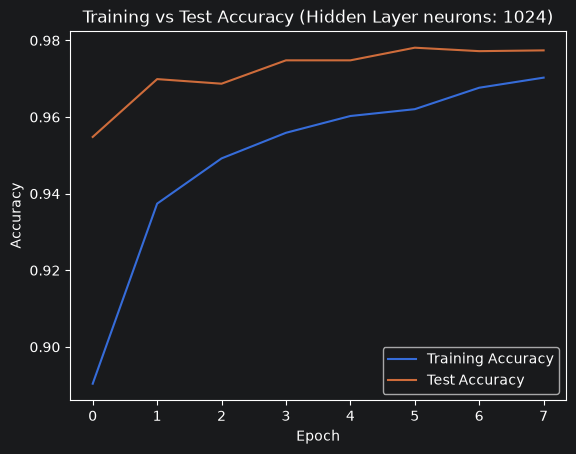

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 48s 24ms/step - accuracy: 0.9019 - loss: 0.3481 - val_accuracy: 0.9520 - val_loss: 0.1512
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 45s 24ms/step - accuracy: 0.9396 - loss: 0.2059 - val_accuracy: 0.9654 - val_loss: 0.1062
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 46s 24ms/step - accuracy: 0.9496 - loss: 0.1710 - val_accuracy: 0.9680 - val_loss: 0.1095
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 46s 24ms/step - accuracy: 0.9560 - loss: 0.1456 - val_accuracy: 0.9729 - val_loss: 0.0923
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 46s 25ms/step - accuracy: 0.9618 - loss: 0.1290 - val_accuracy: 0.9746 - val_loss: 0.0803
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 46s 25ms/step - accuracy: 0.9666 - loss: 0.1088 - val_accuracy: 0.9752 - val_loss: 0.0880
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 46s 24ms/step - accuracy: 0.9700 - loss: 0.0946 - val_accuracy: 0.9773 - val_loss: 0.0817
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 46s 25ms/step - accuracy: 0.9731 -

Model: "functional_39"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_38 (InputLayer)     │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_38 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_132 (Dense)               │ (None, 1024)           │       803,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_133 (Dense)               │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_134 (Dense)               │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_135 (Dense)               │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_136 (Dense)               │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,921,440 (45.48 MB)

 Trainable params: 3,971,082 (15.15 MB)

 Non-trainable params: 8,192 (32.00 KB)

 Optimizer params: 7,942,166 (30.30 MB)

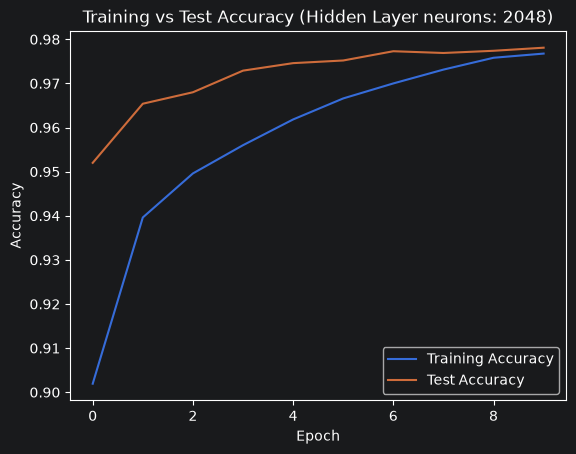

In [29]:
for n in [128, 256,512, 1024]:
    model_numOfNeurons_numOfLayers_numOfEpochs_withDropout_nextLayerHalfNeurons(n, 4, 10)

### notes:

👉 The “turning points” of the decision boundary depend mainly on:

number of layers (depth) → most important
activation functions (nonlinearity) → crucial
number of neurons (width) → affects complexity, but not in a simple “#weights = #turns” way

1. If there were NO hidden layers (just one layer)

Example:

logistic regression or single Dense layer

👉 Decision boundary = a straight line (or hyperplane)
No turning points at all.

2. With 1 hidden layer

Even with just one hidden layer:

👉 The network can form piecewise linear boundaries

So instead of a straight line, you get:

multiple line segments
bends (“turning points”)

But:

The number of bends is roughly related to the number of neurons in the hidden layer, NOT weights.

3. With more layers (deep network)

Adding more layers:

composes these piecewise linear regions
creates much more complex bending
increases the number of possible linear regions exponentially in some cases

👉 So depth increases complexity much more efficiently than width.

🔥 Intuition

Think of it like this:

Each neuron creates a “bend” in space (a ReLU breakpoint)
Each layer recombines those bends
More layers = bends of bends of bends

### difference between number of neurons and number of weights:

DNN
eg: Dense(4, input_dim=28*28)
-num of neurons: 4
-number of weights(one weight per input feature):  28*28*4
-num of parameters: 28*28*4+4(4 bias)

CNN
Input: 28 × 28 (1 channel, like MNIST)
Kernel: 3 × 3
Number of filters: 4
-number of neurons (In CNNs, a “neuron” is often: one value in the feature map. So after convolution: Output shape = 28 × 28 × 4 (assuming stride 1, same padding)):
-number of weights: 3*3*4
-number of parameters: 3*3*4+4

### how does the number of neurons affact the performance

The number of neurons (width of a layer) affects model performance mainly through capacity — how complex a function the network can learn.

🧠 1. More neurons → more learning capacity

Each neuron can learn a different feature.

So if you increase neurons:

the model can represent more patterns
decision boundaries become more flexible
performance can improve (up to a point)

👉 Example:

4 neurons → very simple patterns only
64 neurons → many feature combinations
512 neurons → very expressive model

2. But more is NOT always better

After a certain point:

❌ Too few neurons → underfitting
model is too simple
cannot capture structure in data
both train and test accuracy are low
❌ Too many neurons → overfitting
model memorizes training data
training accuracy high, test accuracy worse
poor generalization

# CNN


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_34 (Flatten)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_114 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_115 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_116 (Dense)               │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,090 (461.29 KB)

 Trainable params: 118,090 (461.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.9262 - loss: 0.2369 - val_accuracy: 0.9743 - val_loss: 0.0845
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9747 - loss: 0.0814 - val_accuracy: 0.9816 - val_loss: 0.0635
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9819 - loss: 0.0585 - val_accuracy: 0.9783 - val_loss: 0.0708
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9861 - loss: 0.0457 - val_accuracy: 0.9846 - val_loss: 0.0528
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9892 - loss: 0.0349 - val_accuracy: 0.9825 - val_loss: 0.0585
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9908 - loss: 0.0281 - val_accuracy: 0.9862 - val_loss: 0.0559
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9921 - loss: 0.0245 - val_accuracy: 0.9861 - val_loss: 0.0535
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9934 - loss: 0

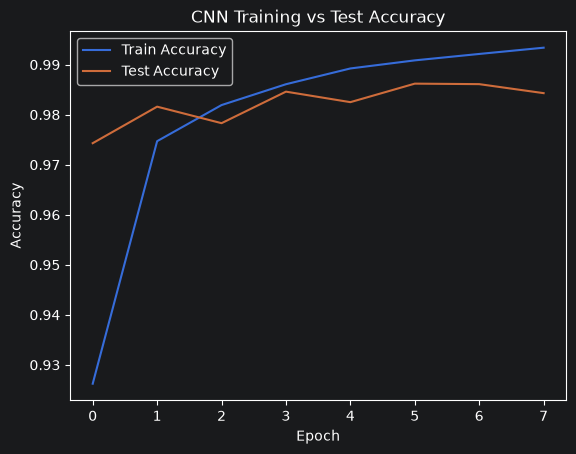

In [28]:
from tensorflow.keras import layers, models

# Add channel dimension (important for CNN)
# The -1 tells Python: “Figure out this dimension automatically”
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Build CNN model
model = models.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),

    # Convolution block 1
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolution block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten + Dense layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])


early_stop = EarlyStopping(
    monitor='val_accuracy',   # or 'val_loss'
    patience=2,               # how many epochs to wait before stopping
    restore_best_weights=True # keeps best model automatically
)

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)



model.summary()

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test, y_test),  # this gives test/validation accuracy per epoch
    callbacks=[early_stop]
)

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Training vs Test Accuracy')
plt.legend()
plt.show()

print(f"Final training accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final test accuracy: {history.history['val_accuracy'][-1]:.4f}")

In [ ]:
def cnn(num_of_layers, num_of_epoch, )